This notebook is a simulation of the parcellation problem. In this notebook we start with a true U with 5 parcels. 

I this simulation I rely on a larger number of potential task - always picking 5 tasks. 

In [1]:
import OptimalBattery.simulate as sim
import OptimalBattery.util as ut
import OptimalBattery.plot as plot
import OptimalBattery.evaluate as ev
import HierarchBayesParcel.spatial as spatial
import HierarchBayesParcel.arrangements as ar
import torch as pt
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import spearmanr
from scipy.stats import ttest_rel
import seaborn as sb


# start with some U_true, in this simulation its 5 tasks x 5 parcels

In [2]:
height = 30
width = 30
K_main = 5
K_subparcels = 1
K_total = 5

grid = spatial.SpatialGrid(height, width)
arrangeT = ar.ArrangeIndependent(K=5, P=grid.P)
# define centroids more systematically
center_1 = (0, 0)
center_5 = (int((height-1)/2), int((width-1)/2))
center_2 = (width-1,0 )
center_4 = (height-1, width-1)
center_3 = (0, height-1)
centroids = [center_1, center_2, center_3, center_4, center_5]
print(centroids)


[(0, 0), (29, 0), (0, 29), (29, 29), (14, 14)]


In [3]:
custom_cmap = plot.create_custom_colormap(['red', 'blue', 'green', 'yellow', 'purple'],K_subparcels=5)

In [4]:
def plot_Us(U,title = None):
    if type(U) == np.ndarray:
        U = pt.tensor(U)
    parcel_labels_plot = U.argmax(dim=0).numpy()
    parcel_labels_plot = parcel_labels_plot.reshape((height, width))
    plt.imshow(parcel_labels_plot, cmap=custom_cmap)
    if title is not None:
        plt.title(title)
    else:
        plt.title('figure')
    return
    

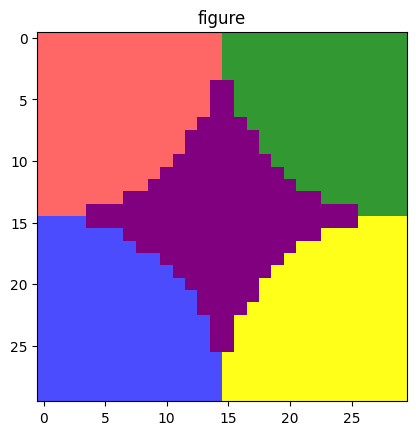

In [5]:
U_true_5 = sim.make_U_spatial(grid, centroids, K_main, K_subparcels)
U_true_5 = pt.tensor(U_true_5, dtype=pt.float32)
arrangeT.logpi = pt.log(U_true_5)

plot_Us(U_true_5)

In [6]:
if type(U_true_5) == pt.Tensor:
    U_true_5 = U_true_5.numpy()

print(type(U_true_5))

if U_true_5.ndim == 2:
    U_true_5 = U_true_5.reshape(1, U_true_5.shape[0], U_true_5.shape[1])

print(U_true_5.shape)

<class 'numpy.ndarray'>
(1, 5, 900)


# Make a random task battery with 30 task and plot second moment matrix

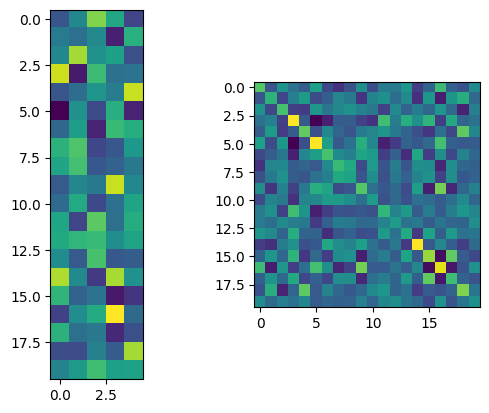

In [7]:
num_task_lib = 20
rng= np.random.default_rng(seed=4)
V_lib = rng.normal(0,1,(num_task_lib, K_main))
V_lib = V_lib - V_lib.mean(axis=0,keepdims=True) 
G_lib = V_lib @ V_lib.T
plt.subplot(1,2,1)
plt.imshow(V_lib, cmap='viridis')
plt.subplot(1,2,2)
plt.imshow(V_lib @ V_lib.T, cmap='viridis')

In [17]:
# try and evaluate random combinations of these task 
noise = 0.4

D = ut.build_combinations(G_lib, strategy='random', n_iter=100, n_tasks=5, seed=2, replacement=False)

# Try the classification of the region voxels
D_ev = ev.sim_evaluate_dataframe_multiregion(D, Y_true, V_lib, U_true_5, sig_e=noise)

,variance,variance_mc,inverse_trace,inverse_trace_mc,log_det,log_det_mc,eigenvalues,num_eigenvalues,n_tasks,combination,n_unique
0,23.055264,19.257052,-8.342362,-1.647312,4.163279,5.144546,"[9.339338660124348, 4.97283560409002, 4.028199...",4,5,"(2, 8, 9, 13, 14)",5
0,29.751398,22.929327,-3.483929,-3.001066,6.112487,4.578025,"[14.340605720479893, 4.51827465991208, 3.66007...",4,5,"(2, 5, 13, 15, 16)",5
0,23.135599,20.148418,-66.677989,-18.919284,1.899857,2.397414,"[10.537106370131117, 6.705148003992184, 2.8515...",4,5,"(5, 8, 12, 14, 19)",5
0,22.508865,19.665347,-25254.475245,-2.025041,-4.444246,4.936836,"[9.610351494666524, 5.376842882130801, 4.00489...",4,5,"(5, 6, 7, 17, 19)",5
0,25.337684,21.619763,-3.039040,-1.624228,5.508951,5.364401,"[11.561534865273982, 5.507839197744921, 3.6247...",4,5,"(6, 8, 11, 14, 15)",5
...,...,...,...,...,...,...,...,...,...,...,...
0,23.564791,19.705380,-3.884628,-2.125078,4.992476,4.671531,"[9.47021867242054, 7.340021709443402, 2.194659...",4,5,"(0, 4, 5, 10, 13)",5
0,18.301250,17.193460,-802.772669,-3.147069,-2.809454,3.343090,"[11.146771228167081, 4.420187516049359, 1.1079...",4,5,"(6, 10, 12, 13, 15)",5
0,23.101083,19.097059,-9.658246,-9.239002,4.243161,2.941300,"[10.258737775292673, 6.1373097769067835, 2.584...",4,5,"(8, 10, 14, 17, 18)",5
0,25.919791,23.131702,-3.490867,-1.407677,5.501059,5.767860,"[10.448115468277697, 8.278889803253323, 3.2759...",4,5,"(2, 3, 4, 7, 17)",5


<Axes: xlabel='log_det_mc', ylabel='variance_mc'>

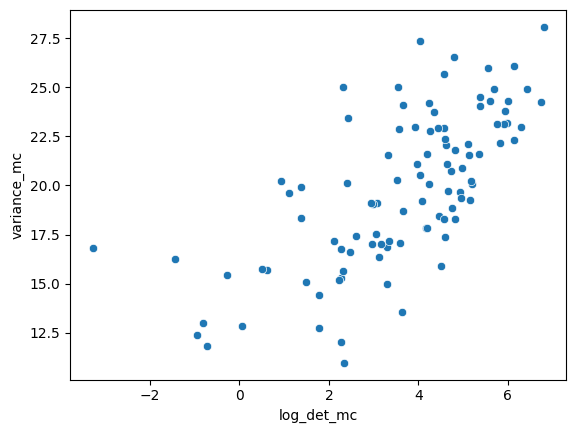

In [23]:
sb.scatterplot(D,x='log_det_mc',y='variance_mc')